# Complement beyond C4b in public datasets: C5, C5a receptors, C1q and Cfb across AD, aging and MS

Extends `analysis_spatial_complement_C5_C1q_Cfb.ipynb` from the in-house spatial data to eight public datasets (see `build_public_datasets.ipynb` for the list). All are whole-transcriptome, so every complement gene is measurable, and seven of them are single-cell / single-nucleus, so oligodendrocyte-intrinsic expression can be separated from neighbouring myeloid cells.

Questions, per dataset:

1. Which coarse cell types express each complement gene (fraction of cells with ≥1 UMI)?
2. Does expression in oligodendrocytes and in microglia change with disease / age (pseudobulk per sample)?
3. Inside oligodendrocytes, which complement genes are co-expressed with C4b, and where do they rank among all genes correlated with C4b?
4. In the human MS data, does the picture hold with human orthologs (C4A/C4B, C5, C5AR1/2, CFB, C1QA-C)?
5. In the spatial AD data (Chen et al.), which complement genes follow C4b across spots and genotype/age?

Mouse symbols are used throughout; human genes are mapped through `MOUSE_TO_HUMAN` (`Hc` → `C5`, `Cd59a` → `CD59`, `Serpina3n` → `SERPINA3`).

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, scipy.sparse as sp, scanpy as sc, seaborn as sns, matplotlib.pyplot as plt
from scipy import stats
import oligoc4b_public as pub
from oligoc4b_public import PANEL, ALL_GENES, FOCUS, MOUSE_TO_HUMAN, COARSE_TYPES

sc.settings.verbosity = 0
sc.set_figure_params(dpi=80, frameon=False)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

PATHS = pub.processed_paths()
for k, v in PATHS.items():
    print(f"{k:36s} {v}")
CONTEXT = ["Serpina3n", "Plp1", "Mbp", "Gfap", "Hexb", "B2m"]

Absinta2021_MS_human_snRNA           /Volumes/jamboree/OligoC4b_public/processed/Absinta2021_MS_human_snRNA.h5ad
Aging_snRNA_HIP_CP_mouse             /Volumes/jamboree/OligoC4b_public/processed/Aging_snRNA_HIP_CP_mouse.h5ad
Chen2020_ST_AppNLGF_mouse            /Volumes/jamboree/OligoC4b_public/processed/Chen2020_ST_AppNLGF_mouse.h5ad
Jakel2019_MS_human_snRNA             /Volumes/jamboree/OligoC4b_public/processed/Jakel2019_MS_human_snRNA.h5ad
Kaya2022_aged_WM_vs_GM_scRNA         /Volumes/jamboree/OligoC4b_public/processed/Kaya2022_aged_WM_vs_GM_scRNA.h5ad
Park2023_AD_hippocampus_scRNA        /Volumes/jamboree/OligoC4b_public/processed/Park2023_AD_hippocampus_scRNA.h5ad
Ximerakis2019_aging_brain_scRNA      /Volumes/jamboree/OligoC4b_public/processed/Ximerakis2019_aging_brain_scRNA.h5ad
Zhou2020_5XFAD_snRNA                 /Volumes/jamboree/OligoC4b_public/processed/Zhou2020_5XFAD_snRNA.h5ad


In [2]:
# ---------- helpers (species-aware versions of the helpers in the in-house notebook) ----------
def sym(species, g):
    return MOUSE_TO_HUMAN.get(g, g.upper()) if species == "human" else g

def resolve(adata, genes):
    # mouse symbol -> actual var name (or None)
    species = adata.obs["species"].iloc[0]
    return {g: (sym(species, g) if sym(species, g) in adata.var_names else None) for g in genes}

def expr(adata, gene):
    x = adata[:, gene].X
    return np.asarray(x.todense()).ravel() if sp.issparse(x) else np.asarray(x).ravel()

def expr_df(adata, genes):
    r = resolve(adata, genes)
    keep = [g for g in genes if r[g] is not None]
    X = adata[:, [r[g] for g in keep]].X
    X = X.toarray() if sp.issparse(X) else np.asarray(X)
    return pd.DataFrame(X, index=adata.obs_names, columns=keep)   # columns are MOUSE symbols

def detection_table(adata, genes, groupby, min_cells=30):
    df = expr_df(adata, genes)
    g = adata.obs[groupby].astype(str).values
    rows = []
    for grp, sub in df.groupby(g):
        if len(sub) < min_cells:
            continue
        row = {"group": grp, "n_cells": len(sub)}
        for gene in df.columns:
            row[gene] = (sub[gene] > 0).mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index("group")

def mean_table(adata, genes, groupby, min_cells=30):
    df = expr_df(adata, genes)
    g = adata.obs[groupby].astype(str).values
    out = df.groupby(g).mean()
    n = pd.Series(g).value_counts()
    return out.loc[n[n >= min_cells].index.intersection(out.index)]

def coexpression_with_anchor(adata, anchor, genes, high_q=0.75):
    df = expr_df(adata, [anchor] + genes)
    if anchor not in df.columns:
        return pd.DataFrame()
    a = df[anchor]; pos = a > 0
    thr = np.quantile(a[pos], high_q) if pos.any() else np.inf
    rows = []
    for g in df.columns:
        if g == anchor:
            continue
        x = df[g]
        f_neg, f_pos = (x[~pos] > 0).mean(), (x[pos] > 0).mean()
        rho = stats.spearmanr(a, x).correlation if x.std() > 0 else np.nan
        tab = [[(x[pos] > 0).sum(), (x[pos] <= 0).sum()], [(x[~pos] > 0).sum(), (x[~pos] <= 0).sum()]]
        try:
            p = stats.fisher_exact(tab)[1]
        except Exception:
            p = np.nan
        rows.append({"gene": g, f"frac_in_{anchor}-": f_neg, f"frac_in_{anchor}+": f_pos, f"frac_in_{anchor}-high": (x[a >= thr] > 0).mean(),
                     "enrichment(+/-)": f_pos / f_neg if f_neg > 0 else np.nan, "spearman_rho": rho, "fisher_p": p})
    return pd.DataFrame(rows).set_index("gene")

def genome_wide_rank(adata, anchor_var, genes_of_interest_vars, min_frac=0.01):
    X = adata.X.toarray() if sp.issparse(adata.X) else np.asarray(adata.X)
    df = pd.DataFrame(X, columns=adata.var_names)
    keep = df.columns[(df > 0).mean() > min_frac]
    a = df[anchor_var].rank()
    rho = df[keep].rank().corrwith(a).drop(anchor_var, errors="ignore").sort_values(ascending=False)
    ranks = pd.DataFrame({"spearman_rho": rho, "rank": np.arange(1, len(rho) + 1)})
    return rho, ranks.loc[[g for g in genes_of_interest_vars if g in ranks.index]]

def pseudobulk(adata, genes, sample_col="sample", extra=("group",)):
    df = expr_df(adata, genes)
    keys = adata.obs[[sample_col] + list(extra)].astype(str)
    return df.join(keys).groupby([sample_col] + list(extra), observed=True).mean().reset_index()

def group_test(pb, gene, group_col, a, b):
    xa, xb = pb.loc[pb[group_col] == a, gene], pb.loc[pb[group_col] == b, gene]
    if len(xa) >= 3 and len(xb) >= 3:
        p = stats.mannwhitneyu(xa, xb, alternative="two-sided").pvalue
    else:
        p = np.nan
    return xa.mean(), xb.mean(), p, len(xa), len(xb)

def other_group(adata):
    ref = adata.obs["group_ref"].iloc[0]
    others = [g for g in adata.obs["group"].unique() if g != ref and g != "unknown"]
    return ref, (others[0] if others else None)

## 1. Load

In [3]:
DATA = {}
for name, path in PATHS.items():
    a = sc.read_h5ad(path)
    a.obs["cell_type_coarse"] = a.obs["cell_type_coarse"].astype(str)
    DATA[name] = a
    print(f"{name:36s} {a.n_obs:>7d} cells  {a.n_vars:>6d} genes  groups={a.obs['group'].value_counts().to_dict()}")

Absinta2021_MS_human_snRNA             66432 cells   27807 genes  groups={'MS': 61141, 'Ctrl': 5291}


Aging_snRNA_HIP_CP_mouse              109822 cells   27213 genes  groups={'Young': 60384, 'Old': 49438}


Chen2020_ST_AppNLGF_mouse              19021 cells   44669 genes  groups={'WT': 9542, 'AD': 9479}
Jakel2019_MS_human_snRNA               17790 cells   21349 genes  groups={'MS': 11199, 'Ctrl': 6591}


Kaya2022_aged_WM_vs_GM_scRNA           29623 cells   20027 genes  groups={'WM': 23391, 'GM': 6232}


Park2023_AD_hippocampus_scRNA          47660 cells   21809 genes  groups={'AD': 27003, 'WT': 20657}


Ximerakis2019_aging_brain_scRNA        37069 cells   14698 genes  groups={'Old': 21041, 'Young': 16028}


Zhou2020_5XFAD_snRNA                  125858 cells   24693 genes  groups={'WT': 69841, 'AD': 56017}


## 2. Which cell types express the complement genes? (fraction of cells with ≥1 UMI)

One row per dataset × coarse cell type. Spatial spots are mixtures and are shown separately in section 6.

n_cells    C4b   C1qa   C1qb   C1qc     C3     Hc  C5ar1  C5ar2    Cfb    C4a  C3ar1  Serpina3n
dataset                         cell_type                                                                                                                 
Absinta2021_MS_human_snRNA      Astrocyte                     8211  0.001  0.012  0.020  0.008  0.075  0.060  0.063  0.002  0.000  0.002  0.002        NaN
                                Immune (lymphoid/myeloid)      406  0.000  0.007  0.025  0.005  0.015  0.010  0.010  0.010  0.000  0.000  0.010        NaN
                                Microglia                     5432  0.000  0.214  0.346  0.238  0.447  0.034  0.112  0.045  0.000  0.000  0.121        NaN
                                Neuron                        2803  0.000  0.009  0.009  0.004  0.013  0.016  0.035  0.009  0.000  0.000  0.002        NaN
                                OPC                           2175  0.000  0.007  0.011  0.005  0.007  0.050  0.005  0.000  0.000  0.000  0.002        NaN
                                Oligodendrocyte              45697  0.000  0.004  0.008  0.004  0.006  0.046  0.006  0.001  0.000  0.000  0.001        NaN
Aging_snRNA_HIP_CP_mouse        Astrocyte                    12690  0.258  0.011  0.012  0.009  0.001  0.002  0.001  0.001  0.005  0.006  0.004      0.013
                                Immune (lymphoid/myeloid)      350  0.011  0.003  0.011  0.006  0.000  0.000  0.000  0.000  0.009  0.009  0.017      0.017
                                Microglia                     3112  0.027  0.291  0.419  0.359  0.000  0.001  0.083  0.070  0.002  0.004  0.091      0.002
                                Neuron                       67036  0.016  0.010  0.011  0.007  0.001  0.001  0.001  0.001  0.010  0.019  0.012      0.012
                                OPC                           4754  0.033  0.012  0.013  0.010  0.000  0.002  0.001  0.001  0.001  0.004  0.004      0.012
                                Oligodendrocyte              19593  0.130  0.013  0.012  0.010  0.000  0.000  0.001  0.001  0.001  0.004  0.003      0.006
Jakel2019_MS_human_snRNA        Astrocyte                     1242  0.003  0.007  0.007  0.006  0.109  0.039  0.010  0.000    NaN  0.003  0.006        NaN
                                Immune (lymphoid/myeloid)      782  0.000  0.019  0.013  0.012  0.006  0.005  0.055  0.006    NaN  0.000  0.010        NaN
                                Microglia                      428  0.000  0.266  0.418  0.343  0.418  0.005  0.091  0.000    NaN  0.000  0.114        NaN
                                Neuron                        5031  0.000  0.006  0.008  0.004  0.008  0.015  0.007  0.001    NaN  0.000  0.001        NaN
                                OPC                            352  0.000  0.006  0.006  0.014  0.011  0.031  0.003  0.000    NaN  0.000  0.000        NaN
                                Oligodendrocyte               7973  0.000  0.006  0.008  0.004  0.010  0.022  0.002  0.000    NaN  0.000  0.001        NaN
Kaya2022_aged_WM_vs_GM_scRNA    Astrocyte                     1933  0.267  0.251  0.247  0.160  0.018  0.004  0.004  0.003  0.001  0.002  0.007      0.053
                                Immune (lymphoid/myeloid)     5877  0.121  0.888  0.885  0.868  0.105  0.000  0.314  0.197  0.004  0.001  0.495      0.028
                                Microglia                     5054  0.100  0.991  0.988  0.984  0.015  0.000  0.384  0.384  0.001  0.000  0.622      0.032
                                Neuron                         546  0.115  0.262  0.225  0.147  0.002  0.000  0.004  0.004  0.000  0.004  0.011      0.027
                                OPC                             90  0.389  0.456  0.411  0.200  0.000  0.011  0.022  0.000  0.000  0.000  0.044      0.222
                                Oligodendrocyte              15776  0.768  0.306  0.285  0.185  0.001  0.000  0.002  0.003  0.000  0.003  0.009      0.417
Park2023_AD_hippocampus_scRNA

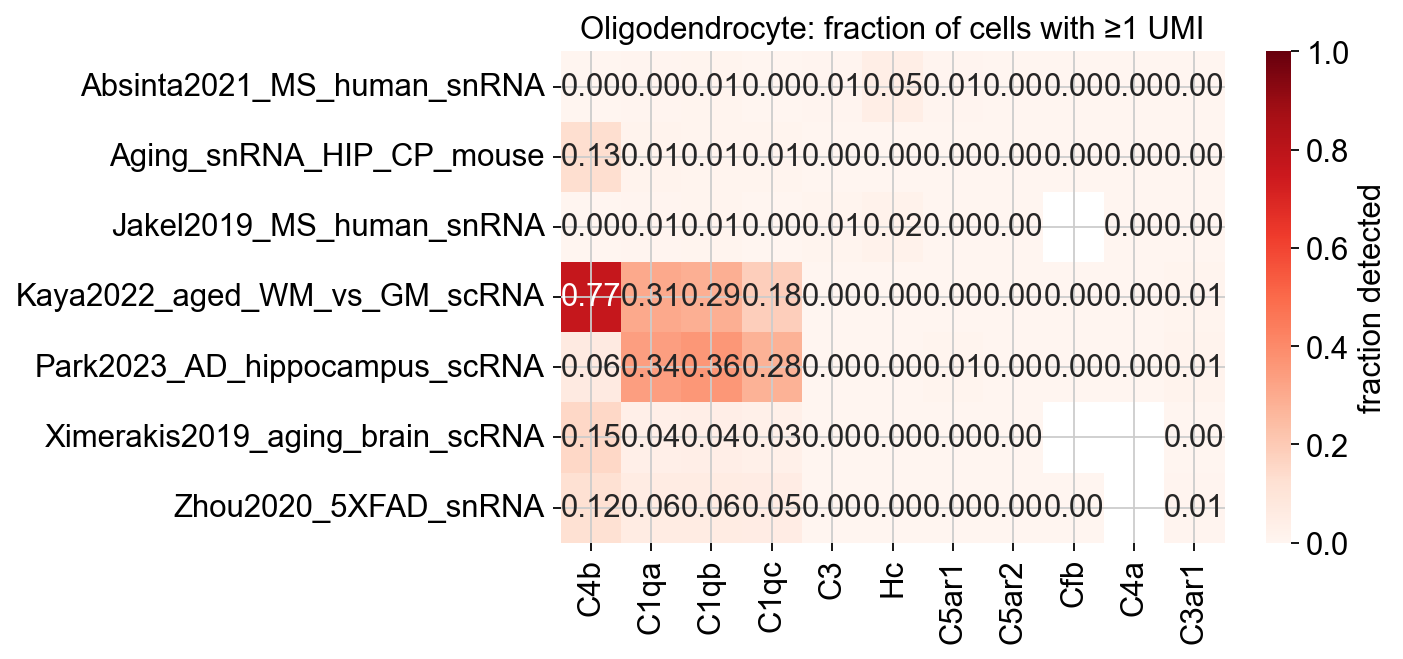

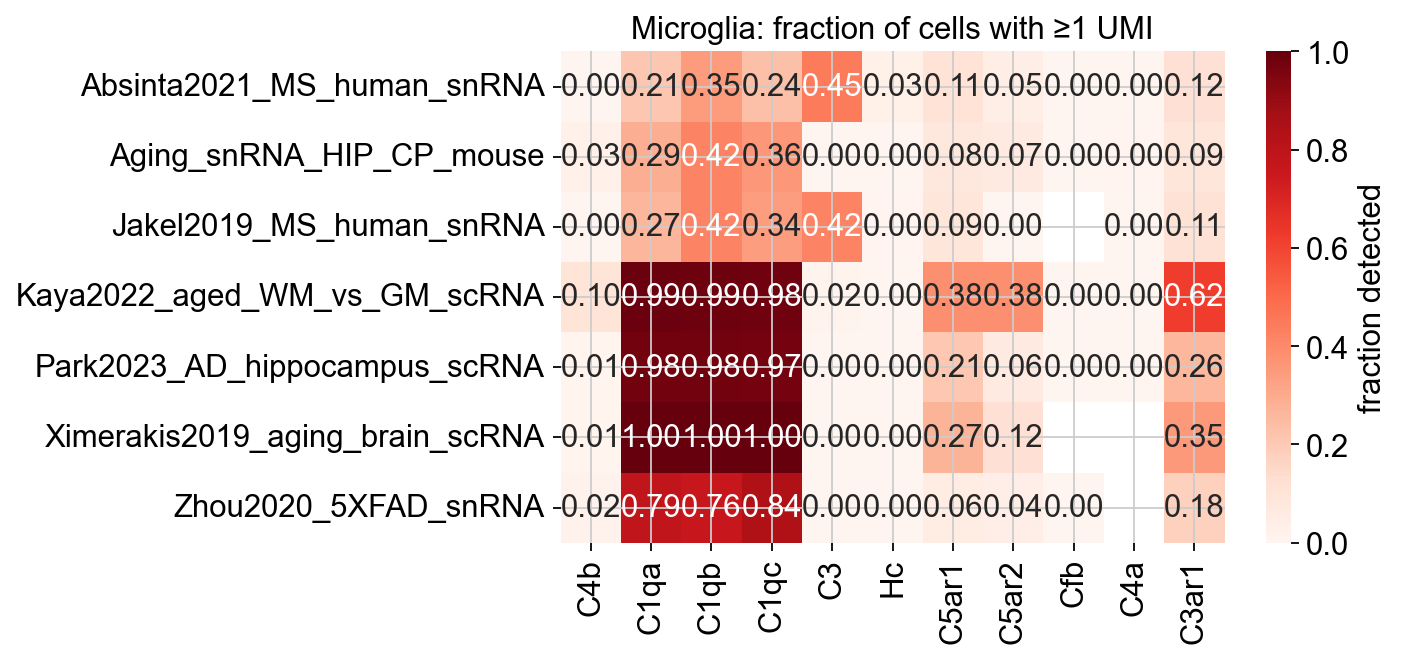

In [4]:
det_rows = []
for name, a in DATA.items():
    if a.obs["modality"].iloc[0] == "spatial":
        continue
    t = detection_table(a, FOCUS + ["C4a", "C3ar1", "Serpina3n"], "cell_type_coarse", min_cells=30)
    t.insert(0, "dataset", name)
    det_rows.append(t.reset_index().rename(columns={"group": "cell_type"}))
DET = pd.concat(det_rows, ignore_index=True)
show = DET[DET.cell_type.isin(["Oligodendrocyte", "OPC", "Microglia", "Astrocyte", "Immune (lymphoid/myeloid)", "Neuron"])]
display(show.set_index(["dataset", "cell_type"]).round(3))
# heatmap: oligodendrocytes and microglia across datasets
for ct in ["Oligodendrocyte", "Microglia"]:
    h = DET[DET.cell_type == ct].set_index("dataset")[FOCUS + ["C4a", "C3ar1"]]
    plt.figure(figsize=(9, 0.45 * len(h) + 1.2))
    sns.heatmap(h, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, cbar_kws={"label": "fraction detected"})
    plt.title(f"{ct}: fraction of cells with ≥1 UMI"); plt.ylabel(""); plt.tight_layout(); plt.show()

## 3. Disease / age effects in oligodendrocytes and microglia (pseudobulk per sample)

Each sample is collapsed to a mean per cell type; groups are compared with a Mann–Whitney test when both groups have ≥3 samples (otherwise the difference is reported without a p-value).

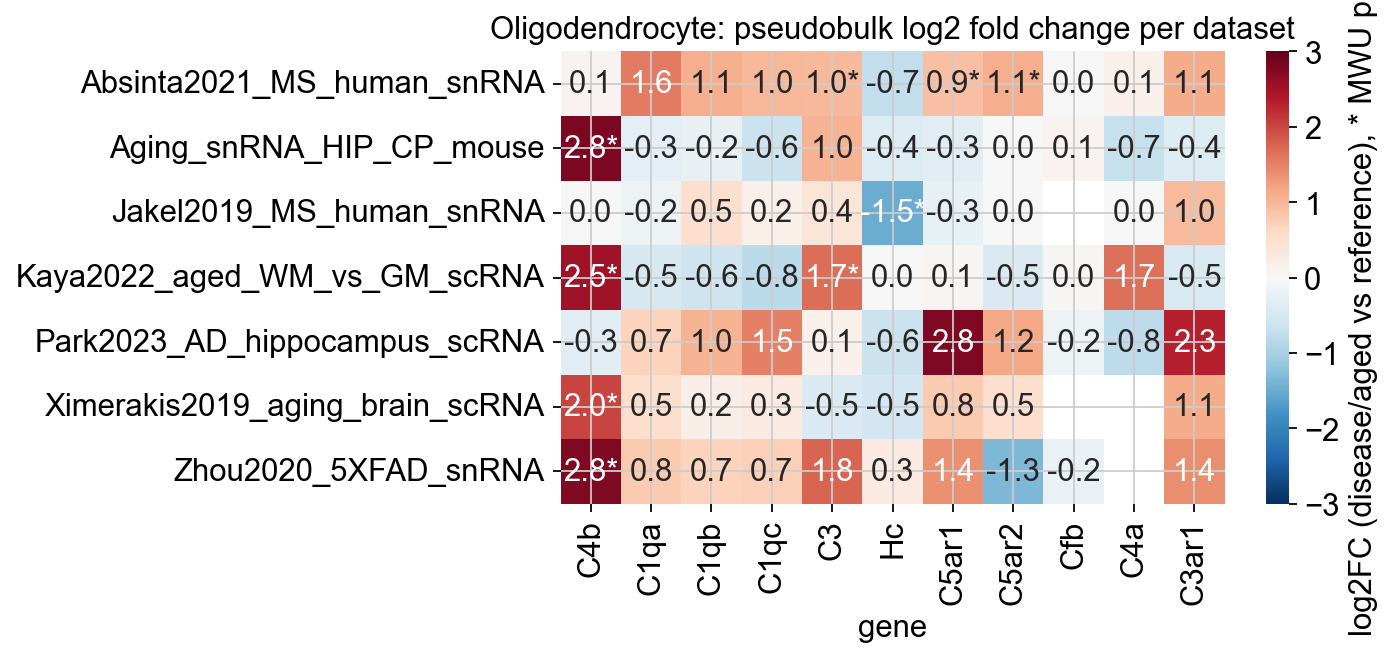

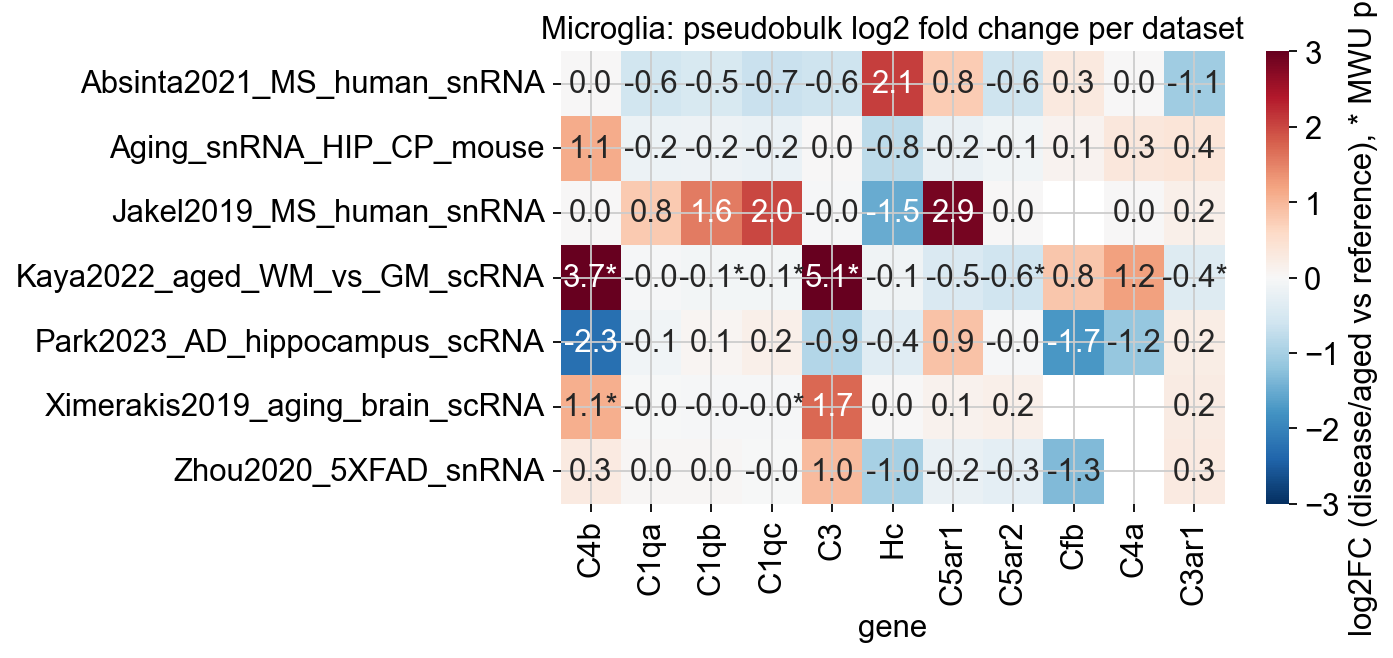

,dataset,cell_type,gene,alt,ref,mean_alt,mean_ref,log2FC,MWU_p,n_alt,n_ref
0,Absinta2021_MS_human_snRNA,Microglia,C1qa,MS,Ctrl,0.3619,0.5353,-0.5636,NaN,5,2
1,Aging_snRNA_HIP_CP_mouse,Microglia,C1qa,Old,Young,0.4370,0.4944,-0.1777,0.6857,4,4
2,Jakel2019_MS_human_snRNA,Microglia,C1qa,MS,Ctrl,0.7841,0.4517,0.7944,NaN,6,1
3,Kaya2022_aged_WM_vs_GM_scRNA,Microglia,C1qa,WM,GM,4.2880,4.3860,-0.0326,0.2500,5,3
4,Park2023_AD_hippocampus_scRNA,Microglia,C1qa,AD,WT,4.2724,4.6085,-0.1092,0.4000,3,3
5,Ximerakis2019_aging_brain_scRNA,Microglia,C1qa,Old,Young,3.1150,3.1540,-0.0179,0.1605,8,8
6,Zhou2020_5XFAD_snRNA,Microglia,C1qa,AD,WT,2.2277,2.1783,0.0323,1.0000,6,6
7,Absinta2021_MS_human_snRNA,Microglia,C3,MS,Ctrl,0.9532,1.4694,-0.6239,NaN,5,2
8,Aging_snRNA_HIP_CP_mouse,Microglia,C3,Old,Young,0.0000,0.0000,0.0000,1.0000,4,4
9,Jakel2019_MS_human_snRNA,Microglia,C3,MS,Ctrl,1.2587,1.2797,-0.0238,NaN,6,1


In [5]:
rows = []
for name, a in DATA.items():
    if a.obs["modality"].iloc[0] == "spatial":
        continue
    ref, alt = other_group(a)
    if alt is None:
        continue
    for ct in ["Oligodendrocyte", "Microglia", "Astrocyte", "Immune (lymphoid/myeloid)"]:
        sub = a[a.obs["cell_type_coarse"] == ct]
        if sub.n_obs < 50:
            continue
        pb = pseudobulk(sub, FOCUS + ["C4a", "C3ar1"])
        n = sub.obs.groupby(["sample"], observed=True).size()
        pb = pb[pb["sample"].map(n) >= 20]
        for g in [c for c in pb.columns if c in FOCUS + ["C4a", "C3ar1"]]:
            ma, mr, p, na, nr = group_test(pb, g, "group", alt, ref)
            rows.append({"dataset": name, "cell_type": ct, "gene": g, "alt": alt, "ref": ref, "mean_alt": ma, "mean_ref": mr,
                         "log2FC": np.log2((ma + 1e-3) / (mr + 1e-3)), "MWU_p": p, "n_alt": na, "n_ref": nr})
DE = pd.DataFrame(rows)
for ct in ["Oligodendrocyte", "Microglia"]:
    d = DE[DE.cell_type == ct].pivot(index="dataset", columns="gene", values="log2FC")[[g for g in FOCUS + ["C4a", "C3ar1"] if g in DE.gene.unique()]]
    p = DE[DE.cell_type == ct].pivot(index="dataset", columns="gene", values="MWU_p").reindex(columns=d.columns)
    annot = d.round(1).astype(str) + np.where(p < 0.05, "*", "")
    plt.figure(figsize=(9, 0.45 * len(d) + 1.2))
    sns.heatmap(d, annot=annot, fmt="", cmap="RdBu_r", center=0, vmin=-3, vmax=3, cbar_kws={"label": "log2FC (disease/aged vs reference), * MWU p<0.05"})
    plt.title(f"{ct}: pseudobulk log2 fold change per dataset"); plt.ylabel(""); plt.tight_layout(); plt.show()
with pd.option_context("display.max_rows", 400):
    display(DE[DE.cell_type.isin(["Oligodendrocyte", "Microglia"]) & DE.gene.isin(["C4b", "C1qa", "C3", "Hc", "C5ar1", "C5ar2", "Cfb"])]
            .sort_values(["cell_type", "gene", "dataset"]).round(4).reset_index(drop=True))

## 4. Co-expression with C4b inside oligodendrocytes

Two views per dataset: (a) is each complement gene detected more often in C4b⁺ than in C4b⁻ oligodendrocytes (Fisher) and how does it correlate (Spearman); (b) rank of each gene among *all* detected genes correlated with C4b in oligodendrocytes, with the top-20 list for context. Human datasets use orthologs.

In [6]:
CO, RANKS, TOP = {}, {}, {}
for name, a in DATA.items():
    if a.obs["modality"].iloc[0] == "spatial":
        continue
    ol = a[a.obs["cell_type_coarse"] == "Oligodendrocyte"].copy()
    ref, alt = other_group(a)
    if ol.n_obs < 100:
        print(f"{name}: too few oligodendrocytes ({ol.n_obs})"); continue
    r = resolve(ol, ["C4b"])
    if r["C4b"] is None:
        print(f"{name}: no C4b ortholog"); continue
    species = ol.obs["species"].iloc[0]
    genes = [g for g in ALL_GENES + ["Serpina3n"] if g != "C4b"]
    co = coexpression_with_anchor(ol, "C4b", genes)
    CO[name] = co
    c4b_var = r["C4b"]
    gi = {sym(species, g): g for g in genes if sym(species, g) in ol.var_names}
    rho, rk = genome_wide_rank(ol, c4b_var, list(gi))
    rk.index = [gi[v] for v in rk.index]
    RANKS[name], TOP[name] = rk, list(rho.head(20).index)
    print(f"\n=== {name}: {ol.n_obs} oligodendrocytes ({(expr(ol, c4b_var) > 0).mean():.1%} C4b+); {len(rho)} genes ranked")
    display(co.join(rk, rsuffix="_rank")[["frac_in_C4b-", "frac_in_C4b+", "enrichment(+/-)", "spearman_rho", "fisher_p", "rank"]].round(4))
    print("top-20 C4b-correlated genes:", ", ".join(TOP[name]))


=== Absinta2021_MS_human_snRNA: 45697 oligodendrocytes (0.0% C4b+); 11756 genes ranked


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p,rank
gene,,,,,,
C4a,0.0001,0.0,0.0000,-0.0000,1.000,NaN
C1qa,0.0039,0.0,0.0000,-0.0003,1.000,NaN
C1qb,0.0080,0.0,0.0000,-0.0004,1.000,NaN
C1qc,0.0036,0.0,0.0000,-0.0003,1.000,NaN
C3,0.0063,0.0,0.0000,-0.0004,1.000,NaN
C3ar1,0.0011,0.0,0.0000,-0.0002,1.000,NaN
Hc,0.0460,0.0,0.0000,-0.0010,1.000,5811.0
C5ar1,0.0055,0.0,0.0000,-0.0003,1.000,NaN
C5ar2,0.0007,0.0,0.0000,-0.0001,1.000,NaN


top-20 C4b-correlated genes: AC073111.5, OR3A2, ING2, HSPA1L, LENG1, MON1B, SLC8A3, PCDHGA1, C11orf80, POP4, UST, LSM10, POLE, PTPRN2, ANKRD24, THAP8, RALYL, CDAN1, KCNQ3, LYG1



=== Aging_snRNA_HIP_CP_mouse: 19593 oligodendrocytes (13.0% C4b+); 13295 genes ranked


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p,rank
gene,,,,,,
C4a,0.0036,0.0031,0.8793,-0.0042,0.8585,NaN
C1qa,0.0127,0.0114,0.8960,-0.0041,0.6337,7317.0
C1qb,0.0117,0.0106,0.9097,-0.0038,0.7649,7160.0
C1qc,0.0100,0.0075,0.7493,-0.0091,0.2760,NaN
C3,0.0004,0.0000,0.0000,-0.0067,1.0000,NaN
C3ar1,0.0033,0.0031,0.9410,-0.0012,1.0000,NaN
Hc,0.0001,0.0004,3.3523,0.0075,0.3410,NaN
C5ar1,0.0005,0.0004,0.7450,-0.0018,1.0000,NaN
C5ar2,0.0008,0.0008,1.0315,-0.0009,1.0000,NaN


...

,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p,rank
gene,,,,,,
C1qa,0.0368,0.0511,1.3881,0.0199,0.0039,2824.0
C1qb,0.0403,0.0459,1.1372,0.0068,0.2608,6589.0
C1qc,0.0278,0.0339,1.2181,0.0094,0.1575,5920.0
C3,0.0001,0.0000,0.0000,-0.0038,1.0000,NaN
C3ar1,0.0011,0.0016,1.3633,0.0047,0.7173,NaN
Hc,0.0003,0.0000,0.0000,-0.0066,1.0000,NaN
C5ar1,0.0002,0.0005,2.7267,0.0062,0.3966,NaN
C5ar2,0.0002,0.0000,0.0000,-0.0054,1.0000,NaN
Cfh,0.0012,0.0021,1.6780,0.0067,0.3208,NaN


top-20 C4b-correlated genes: Serpina3n, H2-D1, B2m, Hopx, Ifi27, Ifi27l2a, Cela1, 7630403G23Rik, Gadd45a, Csf1, Cbs, Stat3, Flnc, Tubb3, St8sia5, Irf9, Rab3b, Rnase4, Tmem59l, Lbh



=== Zhou2020_5XFAD_snRNA: 17356 oligodendrocytes (12.4% C4b+); 11527 genes ranked


,frac_in_C4b-,frac_in_C4b+,enrichment(+/-),spearman_rho,fisher_p,rank
gene,,,,,,
C1qa,0.0554,0.0687,1.2399,0.0170,0.0149,233.0
C1qb,0.0539,0.0640,1.1871,0.0117,0.0620,482.0
C1qc,0.0526,0.0626,1.1903,0.0117,0.0591,477.0
C3,0.0001,0.0009,7.0538,0.0198,0.0779,NaN
C3ar1,0.0053,0.0070,1.3226,0.0063,0.3469,NaN
Hc,0.0002,0.0000,0.0000,-0.0049,1.0000,NaN
C5ar1,0.0023,0.0042,1.8138,0.0105,0.1092,NaN
C5ar2,0.0015,0.0014,0.9201,-0.0015,1.0000,NaN
Cfb,0.0001,0.0000,0.0000,-0.0040,1.0000,NaN


top-20 C4b-correlated genes: Serpina3n, Klk6, Ttr, H2-D1, Trf, Neat1, Malat1, Apod, Cd9, Cldn11, mt-Atp6, Cd63, Gfap, Apoe, Fbl, Aldh1l2, Ifi27, H2-K1, Gm26870, B2m


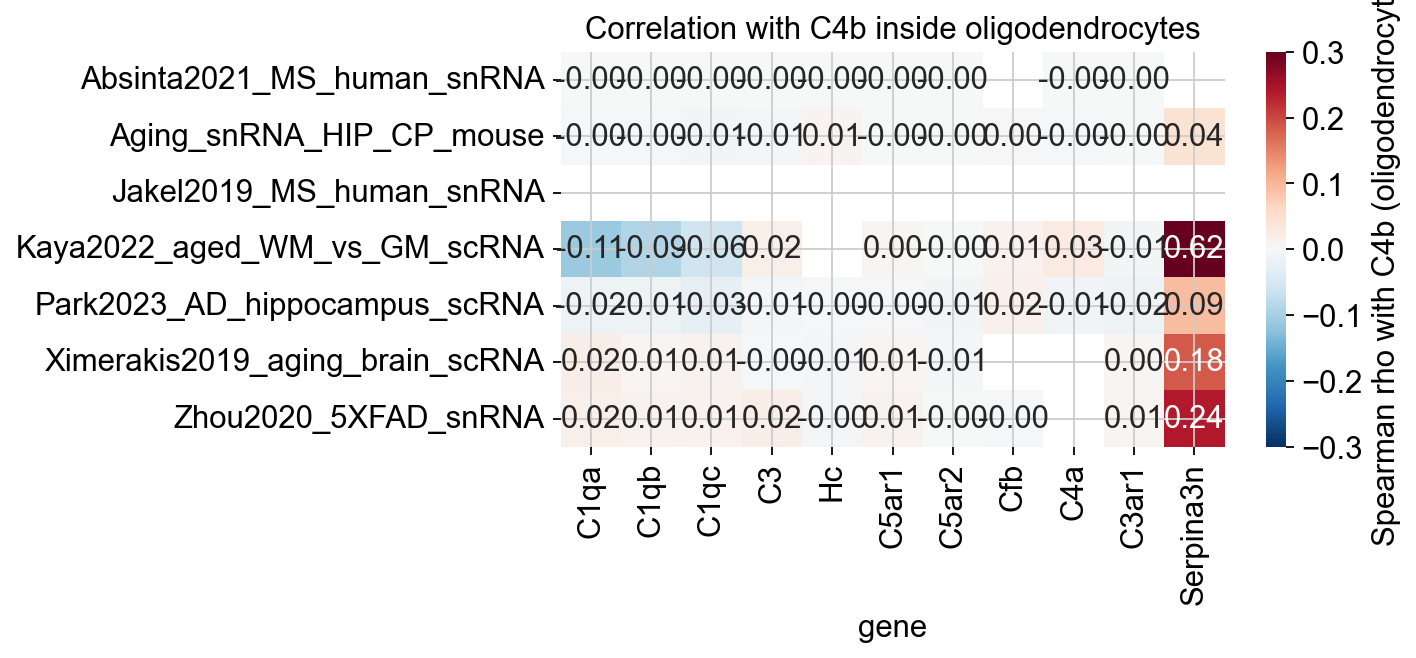

rank among all detected genes (1 = most C4b-correlated):


gene,C1qa,C1qb,C1qc,C3,Hc,C5ar1,C5ar2,Cfb,C4a,C3ar1,Serpina3n
Absinta2021_MS_human_snRNA,NaN,NaN,NaN,NaN,5811.0,NaN,NaN,NaN,NaN,NaN,NaN
Aging_snRNA_HIP_CP_mouse,7317.0,7160.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Jakel2019_MS_human_snRNA,NaN,NaN,NaN,4501.0,9336.0,NaN,NaN,NaN,NaN,NaN,NaN
Kaya2022_aged_WM_vs_GM_scRNA,11457.0,11382.0,11162.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
Park2023_AD_hippocampus_scRNA,10666.0,10649.0,10868.0,NaN,NaN,NaN,NaN,NaN,NaN,10673.0,109.0
Ximerakis2019_aging_brain_scRNA,2824.0,6589.0,5920.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
Zhou2020_5XFAD_snRNA,233.0,482.0,477.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [7]:
# summary heatmap: Spearman rho with C4b in oligodendrocytes, per dataset
R = pd.DataFrame({k: v["spearman_rho"] for k, v in CO.items()}).T
R = R[[g for g in FOCUS + ["C4a", "C3ar1", "Serpina3n"] if g in R.columns and g != "C4b"]]
plt.figure(figsize=(9, 0.45 * len(R) + 1.2))
sns.heatmap(R, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.3, cbar_kws={"label": "Spearman rho with C4b (oligodendrocytes)"})
plt.title("Correlation with C4b inside oligodendrocytes"); plt.ylabel(""); plt.tight_layout(); plt.show()
RK = pd.DataFrame({k: v["rank"] for k, v in RANKS.items()}).T.reindex(columns=R.columns)
print("rank among all detected genes (1 = most C4b-correlated):"); display(RK)

## 5. Human MS (Jäkel 2019, Absinta 2021): complement by lesion type

Uses the authors' lesion / tissue labels (`condition_original`) so that active lesion rims, cores, normal-appearing white matter and controls can be told apart. The first cell checks whether human C4A/C4B are quantifiable at all (they are near-identical paralogs, and multi-mapping reads are dropped by Cell Ranger).

In [8]:
# Can human C4 be quantified at all? C4A and C4B are near-identical paralogs; multi-mapping reads are discarded by Cell Ranger.
for name in [n for n in DATA if DATA[n].obs["species"].iloc[0] == "human"]:
    a = DATA[name]
    rows = []
    for g in ["C4A", "C4B", "C5", "C5AR1", "C5AR2", "CFB", "C3", "C1QA", "PLP1"]:
        if g in a.var_names:
            L = a[:, g].layers["counts"]; L = L.toarray().ravel() if sp.issparse(L) else np.asarray(L).ravel()
            rows.append({"gene": g, "total_UMIs": int(L.sum()), "nuclei_detected": int((L > 0).sum()), "n_nuclei": a.n_obs})
    print(name); display(pd.DataFrame(rows).set_index("gene"))

Absinta2021_MS_human_snRNA


,total_UMIs,nuclei_detected,n_nuclei
gene,,,
C4A,22,22,66432
C4B,12,12,66432
C5,3413,2988,66432
C5AR1,1854,1522,66432
C5AR2,344,321,66432
CFB,6,6,66432
C3,6490,3443,66432
C1QA,2194,1506,66432
PLP1,780566,50652,66432


Jakel2019_MS_human_snRNA


,total_UMIs,nuclei_detected,n_nuclei
gene,,,
C4A,5,5,17790
C4B,6,4,17790
C5,380,359,17790
C5AR1,190,165,17790
C5AR2,10,10,17790
C3,765,580,17790
C1QA,447,317,17790
PLP1,139859,11263,17790



=== Absinta2021_MS_human_snRNA ===  condition labels: {'chronic_active_MS_lesion_edge': 21522, 'MS_periplaque_white_matter': 19770, 'chronic_inactive_MS_lesion_edge': 15510, 'control_white_matter': 5291, 'MS_lesion_core': 4339}


-- Oligodendrocyte: fraction detected by lesion type


,n_cells,C4b,C1qa,C1qb,C1qc,C3,Hc,C5ar1,C5ar2,Cfb,C4a,C3ar1
group,,,,,,,,,,,,
MS_periplaque_white_matter,17563,0.0,0.001,0.003,0.001,0.006,0.056,0.008,0.001,0.0,0.0,0.001
chronic_active_MS_lesion_edge,12658,0.0,0.010,0.018,0.009,0.009,0.039,0.005,0.001,0.0,0.0,0.002
chronic_inactive_MS_lesion_edge,11193,0.0,0.003,0.006,0.003,0.004,0.031,0.003,0.000,0.0,0.0,0.000
control_white_matter,4264,0.0,0.001,0.004,0.002,0.003,0.070,0.003,0.000,0.0,0.0,0.000


-- Microglia: fraction detected by lesion type


,n_cells,C4b,C1qa,C1qb,C1qc,C3,Hc,C5ar1,C5ar2,Cfb,C4a,C3ar1
group,,,,,,,,,,,,
MS_lesion_core,651,0.0,0.220,0.378,0.215,0.558,0.055,0.108,0.025,0.0,0.0,0.147
MS_periplaque_white_matter,772,0.0,0.168,0.273,0.140,0.438,0.017,0.066,0.022,0.0,0.0,0.054
chronic_active_MS_lesion_edge,2873,0.0,0.221,0.365,0.261,0.424,0.036,0.145,0.062,0.0,0.0,0.123
chronic_inactive_MS_lesion_edge,847,0.0,0.217,0.315,0.253,0.407,0.032,0.070,0.026,0.0,0.0,0.126
control_white_matter,289,0.0,0.253,0.374,0.287,0.574,0.021,0.045,0.042,0.0,0.0,0.201


-- Immune (lymphoid/myeloid): fraction detected by lesion type


,n_cells,C4b,C1qa,C1qb,C1qc,C3,Hc,C5ar1,C5ar2,Cfb,C4a,C3ar1
group,,,,,,,,,,,,
MS_periplaque_white_matter,81,0.0,0.000,0.000,0.000,0.000,0.012,0.000,0.000,0.0,0.0,0.025
chronic_active_MS_lesion_edge,219,0.0,0.014,0.046,0.009,0.018,0.009,0.014,0.014,0.0,0.0,0.005
chronic_inactive_MS_lesion_edge,66,0.0,0.000,0.000,0.000,0.015,0.000,0.015,0.000,0.0,0.0,0.000


-- Astrocyte: fraction detected by lesion type


,n_cells,C4b,C1qa,C1qb,C1qc,C3,Hc,C5ar1,C5ar2,Cfb,C4a,C3ar1
group,,,,,,,,,,,,
MS_lesion_core,1687,0.000,0.011,0.012,0.005,0.016,0.074,0.156,0.001,0.0,0.001,0.001
MS_periplaque_white_matter,469,0.000,0.006,0.013,0.002,0.096,0.062,0.021,0.000,0.0,0.000,0.002
chronic_active_MS_lesion_edge,4046,0.002,0.015,0.030,0.012,0.106,0.059,0.043,0.003,0.0,0.003,0.002
chronic_inactive_MS_lesion_edge,1681,0.001,0.010,0.008,0.001,0.059,0.046,0.045,0.000,0.0,0.001,0.002
control_white_matter,328,0.000,0.003,0.000,0.006,0.058,0.076,0.000,0.000,0.0,0.000,0.000


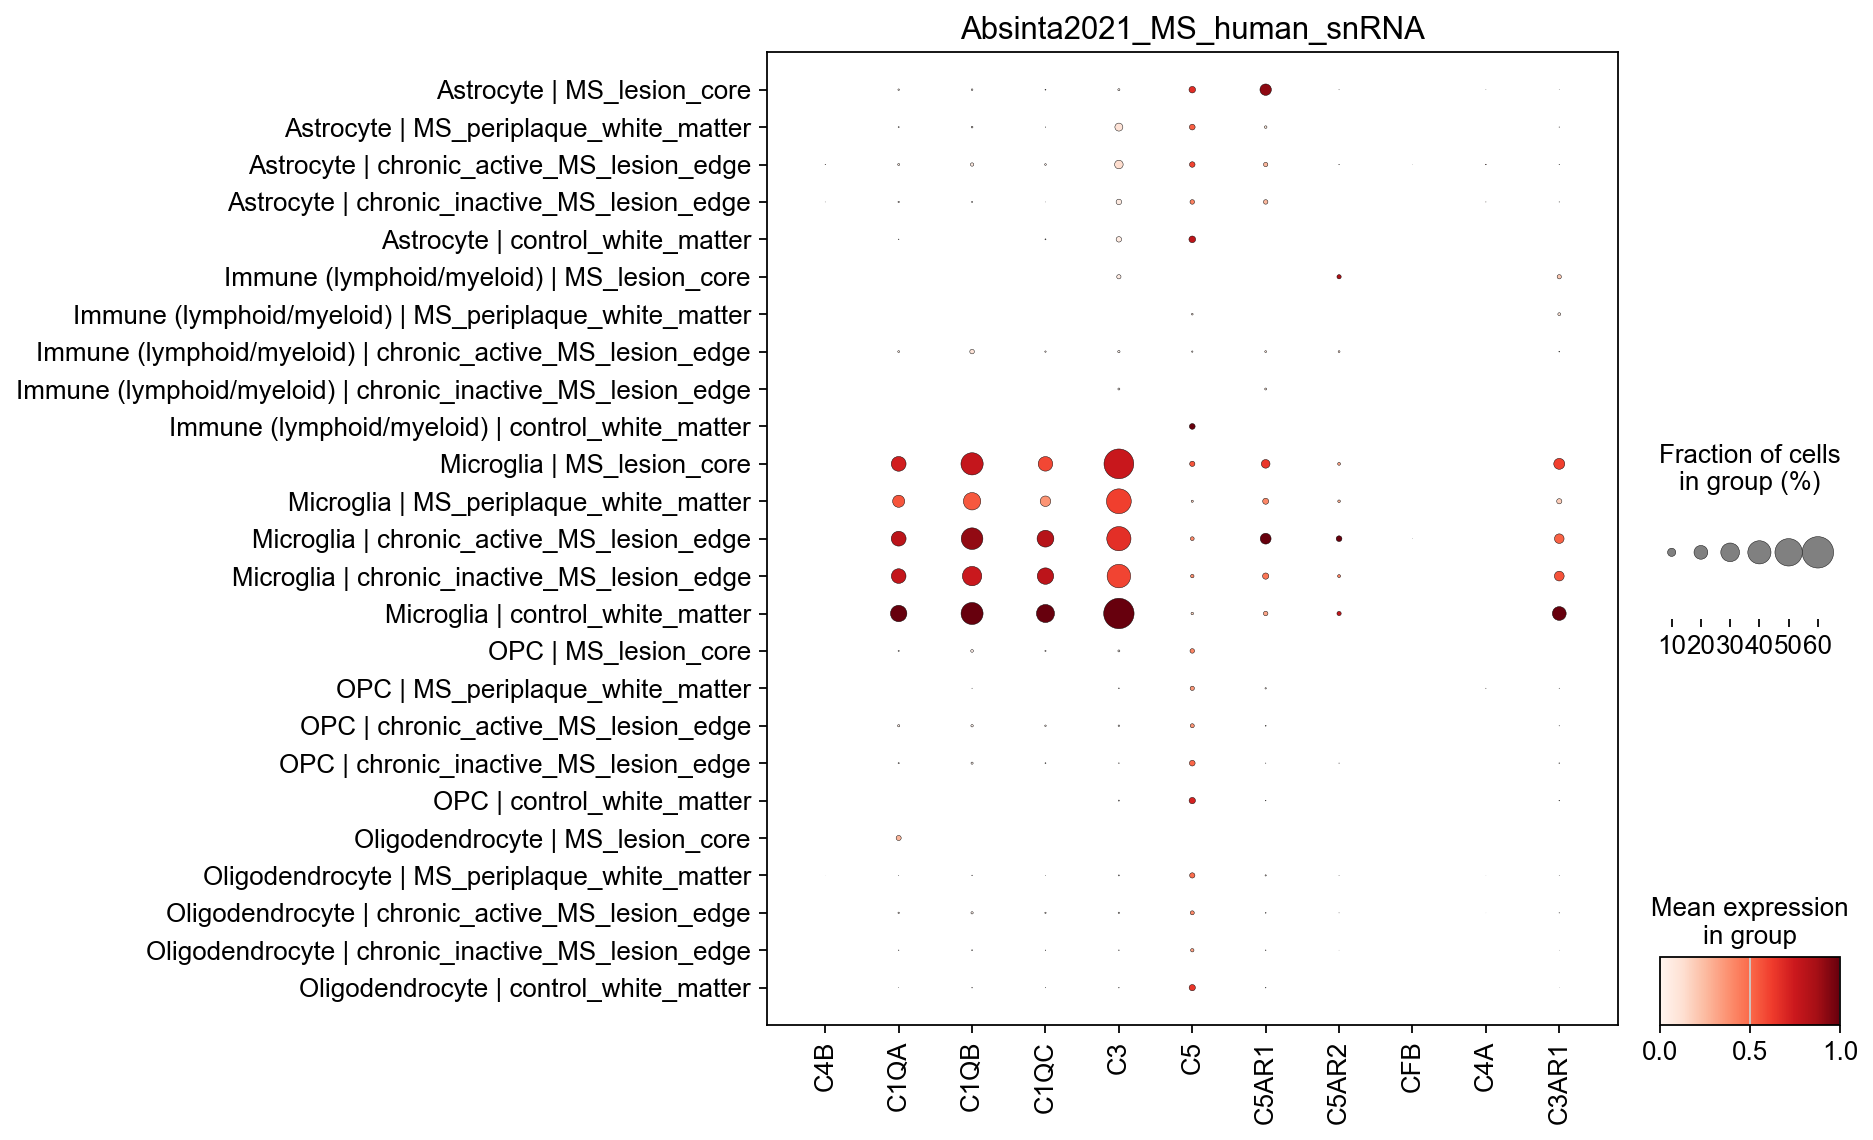


=== Jakel2019_MS_human_snRNA ===  condition labels: {'Ctrl': 6591, 'NAWM': 4287, 'A': 2803, 'CI': 1987, 'CA': 1640, 'RM': 482}
-- Oligodendrocyte: fraction detected by lesion type


,n_cells,C4b,C1qa,C1qb,C1qc,C3,Hc,C5ar1,C5ar2,C4a,C3ar1
group,,,,,,,,,,,
A,1102,0.0,0.005,0.007,0.004,0.012,0.012,0.000,0.0,0.0,0.001
CA,435,0.0,0.002,0.009,0.005,0.011,0.014,0.005,0.0,0.0,0.002
CI,1068,0.0,0.003,0.009,0.003,0.009,0.017,0.001,0.0,0.0,0.001
Ctrl,3530,0.0,0.006,0.008,0.004,0.009,0.034,0.002,0.0,0.0,0.000
NAWM,1478,0.0,0.008,0.009,0.005,0.014,0.014,0.001,0.0,0.0,0.001
RM,360,0.0,0.006,0.003,0.000,0.006,0.000,0.000,0.0,0.0,0.000


-- Microglia: fraction detected by lesion type


,n_cells,C4b,C1qa,C1qb,C1qc,C3,Hc,C5ar1,C5ar2,C4a,C3ar1
group,,,,,,,,,,,
A,218,0.0,0.243,0.417,0.362,0.390,0.000,0.119,0.0,0.0,0.092
CA,41,0.0,0.195,0.341,0.293,0.463,0.000,0.122,0.0,0.0,0.171
CI,32,0.0,0.469,0.625,0.500,0.469,0.031,0.125,0.0,0.0,0.156
Ctrl,78,0.0,0.256,0.295,0.192,0.423,0.013,0.026,0.0,0.0,0.115
NAWM,57,0.0,0.298,0.526,0.421,0.474,0.000,0.035,0.0,0.0,0.123


-- Immune (lymphoid/myeloid): fraction detected by lesion type


,n_cells,C4b,C1qa,C1qb,C1qc,C3,Hc,C5ar1,C5ar2,C4a,C3ar1
group,,,,,,,,,,,
A,325,0.0,0.015,0.006,0.006,0.012,0.009,0.04,0.000,0.0,0.000
CA,412,0.0,0.017,0.007,0.012,0.002,0.002,0.07,0.012,0.0,0.017


-- Astrocyte: fraction detected by lesion type


,n_cells,C4b,C1qa,C1qb,C1qc,C3,Hc,C5ar1,C5ar2,C4a,C3ar1
group,,,,,,,,,,,
A,166,0.024,0.012,0.006,0.012,0.181,0.036,0.006,0.0,0.012,0.006
CA,232,0.000,0.000,0.009,0.004,0.086,0.013,0.000,0.0,0.009,0.000
CI,115,0.000,0.000,0.000,0.009,0.087,0.035,0.035,0.0,0.000,0.009
Ctrl,454,0.000,0.011,0.002,0.004,0.121,0.053,0.002,0.0,0.000,0.009
NAWM,244,0.000,0.008,0.020,0.004,0.061,0.049,0.029,0.0,0.000,0.004
RM,31,0.000,0.000,0.000,0.000,0.161,0.000,0.000,0.0,0.000,0.000


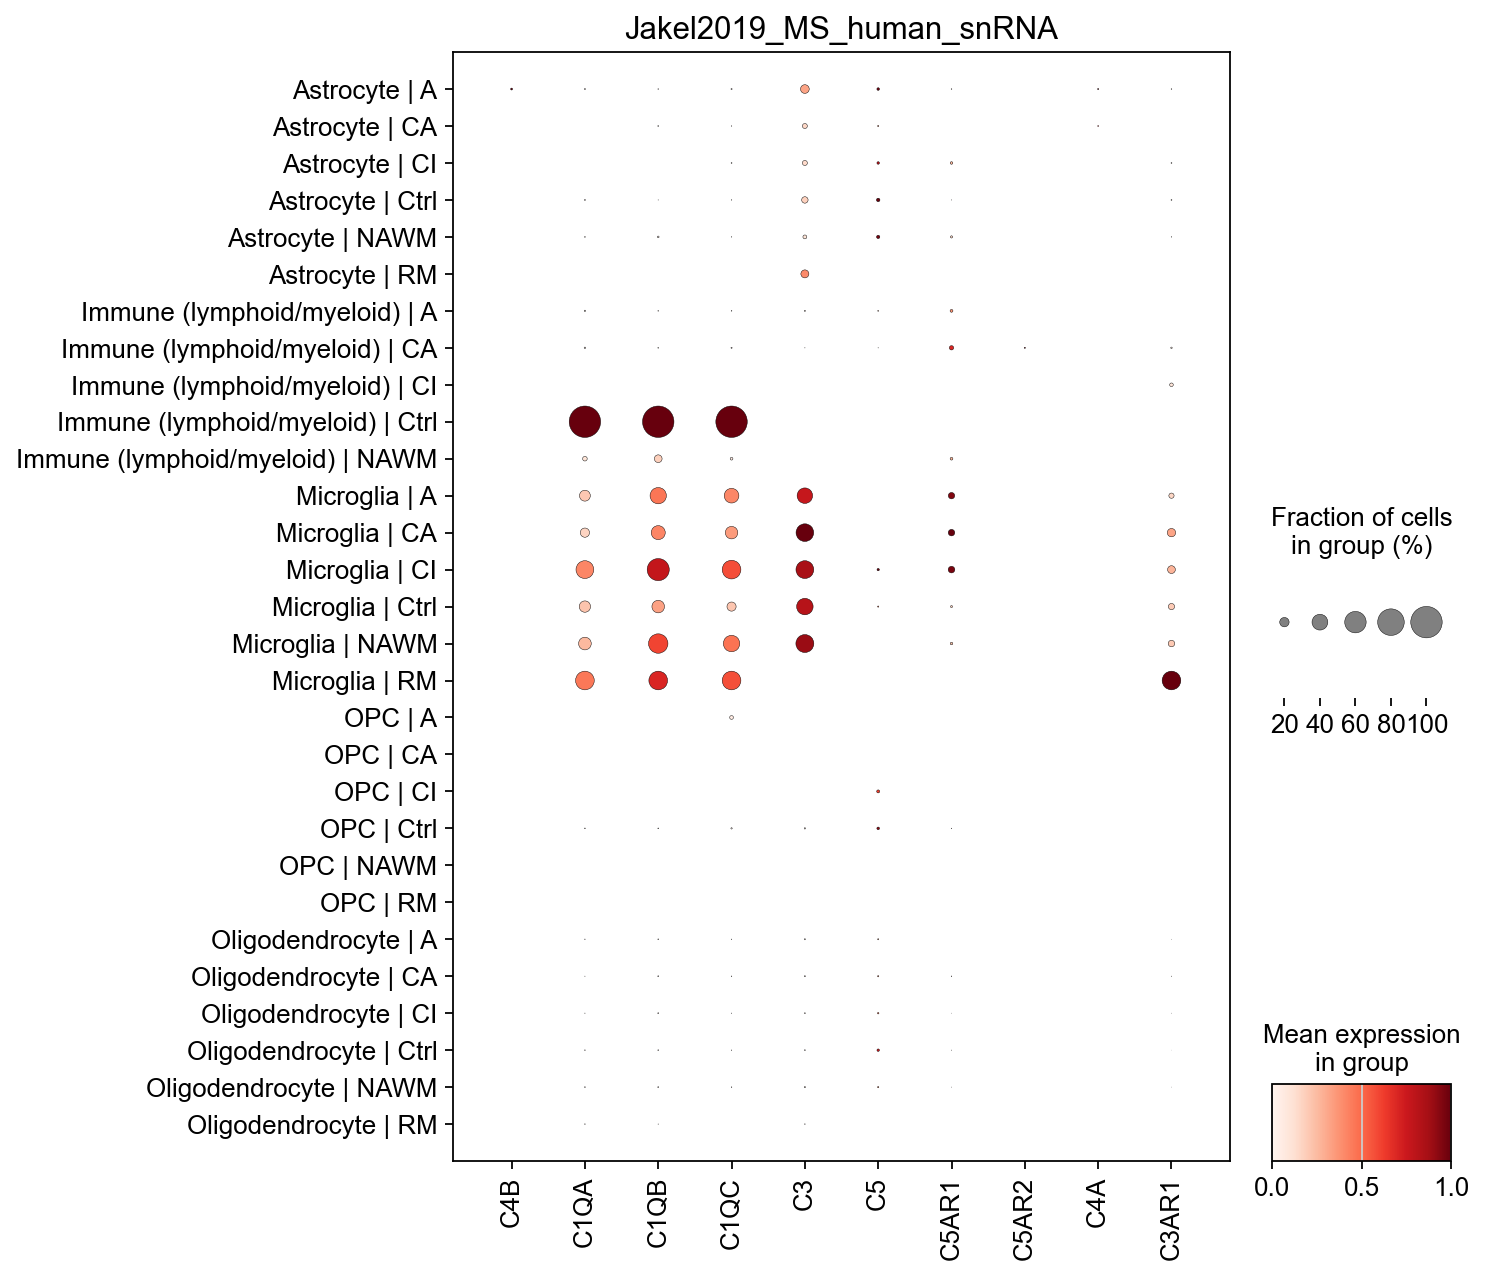

In [9]:
for name in [n for n in DATA if DATA[n].obs["species"].iloc[0] == "human"]:
    a = DATA[name]
    genes = FOCUS + ["C4a", "C3ar1", "Serpina3n"]
    print(f"\n=== {name} ===  condition labels: {a.obs['condition_original'].astype(str).value_counts().to_dict()}")
    for ct in ["Oligodendrocyte", "Microglia", "Immune (lymphoid/myeloid)", "Astrocyte"]:
        sub = a[a.obs["cell_type_coarse"] == ct]
        if sub.n_obs < 50:
            continue
        t = detection_table(sub, genes, "condition_original", min_cells=30)
        print(f"-- {ct}: fraction detected by lesion type"); display(t.round(3))
    # dotplot with human symbols
    r = resolve(a, genes)
    hv = [r[g] for g in genes if r[g] is not None]
    a.obs["ct_cond"] = a.obs["cell_type_coarse"].astype(str) + " | " + a.obs["condition_original"].astype(str)
    keep = a.obs["cell_type_coarse"].isin(["Oligodendrocyte", "Microglia", "Immune (lymphoid/myeloid)", "Astrocyte", "OPC"])
    sc.pl.dotplot(a[keep], var_names=hv, groupby="ct_cond", standard_scale="var", color_map="Reds", figsize=(0.6 * len(hv) + 2, 0.28 * a.obs.loc[keep, "ct_cond"].nunique() + 1), show=False, title=name)
    plt.show()

## 6. Spatial AD (Chen et al. 2020, Spatial Transcriptomics): complement across spots

Whole-transcriptome spots (~100 µm). C4b is one of the plaque-induced genes (PIGs) in this dataset; the question is which other complement genes track it across spots, genotype and age.

=== Chen2020_ST_AppNLGF_mouse: 19021 spots, samples=20, groups={'WT': 9542, 'AD': 9479}
mean log-expression by genotype x age:


,C4b,C1qa,C1qb,C1qc,C3,Hc,C5ar1,C5ar2,Cfb,C4a,C3ar1,Serpina3n
WT_3M,0.099,0.267,0.328,0.282,0.011,0.008,0.005,0.005,0.001,0.058,0.015,0.149
AD_3M,0.092,0.259,0.292,0.310,0.008,0.005,0.003,0.005,0.001,0.048,0.019,0.131
WT_18M,0.187,0.254,0.286,0.299,0.013,0.006,0.005,0.005,0.000,0.106,0.019,0.135
AD_18M,0.754,0.778,0.815,0.794,0.023,0.005,0.008,0.007,0.001,0.454,0.065,0.543
WT_6M,0.072,0.150,0.163,0.165,0.011,0.007,0.005,0.002,0.000,0.043,0.015,0.059
AD_6M,0.114,0.168,0.200,0.207,0.008,0.006,0.004,0.000,0.000,0.066,0.023,0.064
WT_12M,0.119,0.229,0.257,0.234,0.016,0.011,0.009,0.006,0.000,0.075,0.014,0.103
AD_12M,0.463,0.585,0.682,0.606,0.024,0.013,0.005,0.010,0.001,0.331,0.055,0.380


co-expression with C4b across spots:


,frac_in_C4b-,frac_in_C4b+,frac_in_C4b-high,enrichment(+/-),spearman_rho,fisher_p,rank
gene,,,,,,,
C1qa,0.5040,0.7346,0.7961,1.4576,0.3479,0.0000,11.0
C1qb,0.5542,0.7629,0.8267,1.3767,0.3346,0.0000,15.0
C1qc,0.5208,0.7320,0.7986,1.4054,0.3156,0.0000,18.0
C3,0.0280,0.0515,0.0651,1.8399,0.0682,0.0000,986.0
Hc,0.0187,0.0217,0.0175,1.1617,0.0031,0.1557,13750.0
C5ar1,0.0129,0.0198,0.0185,1.5391,0.0242,0.0002,5564.0
C5ar2,0.0157,0.0187,0.0215,1.1914,0.0096,0.1240,10575.0
Cfb,0.0014,0.0026,0.0025,1.8156,0.0121,0.0940,NaN
C4a,0.1220,0.5581,0.8071,4.5740,0.5627,0.0000,1.0


top-30 C4b-correlated genes across spots: C4a, Cst7, Gfap, Ctsd, Tyrobp, Cst3, Lyz2, Trem2, Apoe, B2m, C1qa, Ctss, Ccl6, Ly86, C1qb, Cd74, Serpina3n, C1qc, Clec7a, Hexb, Fth1, Ctsz, Itgax, Mpeg1, Clu, Cd52, Trf, Cd9, Lag3, Laptm5


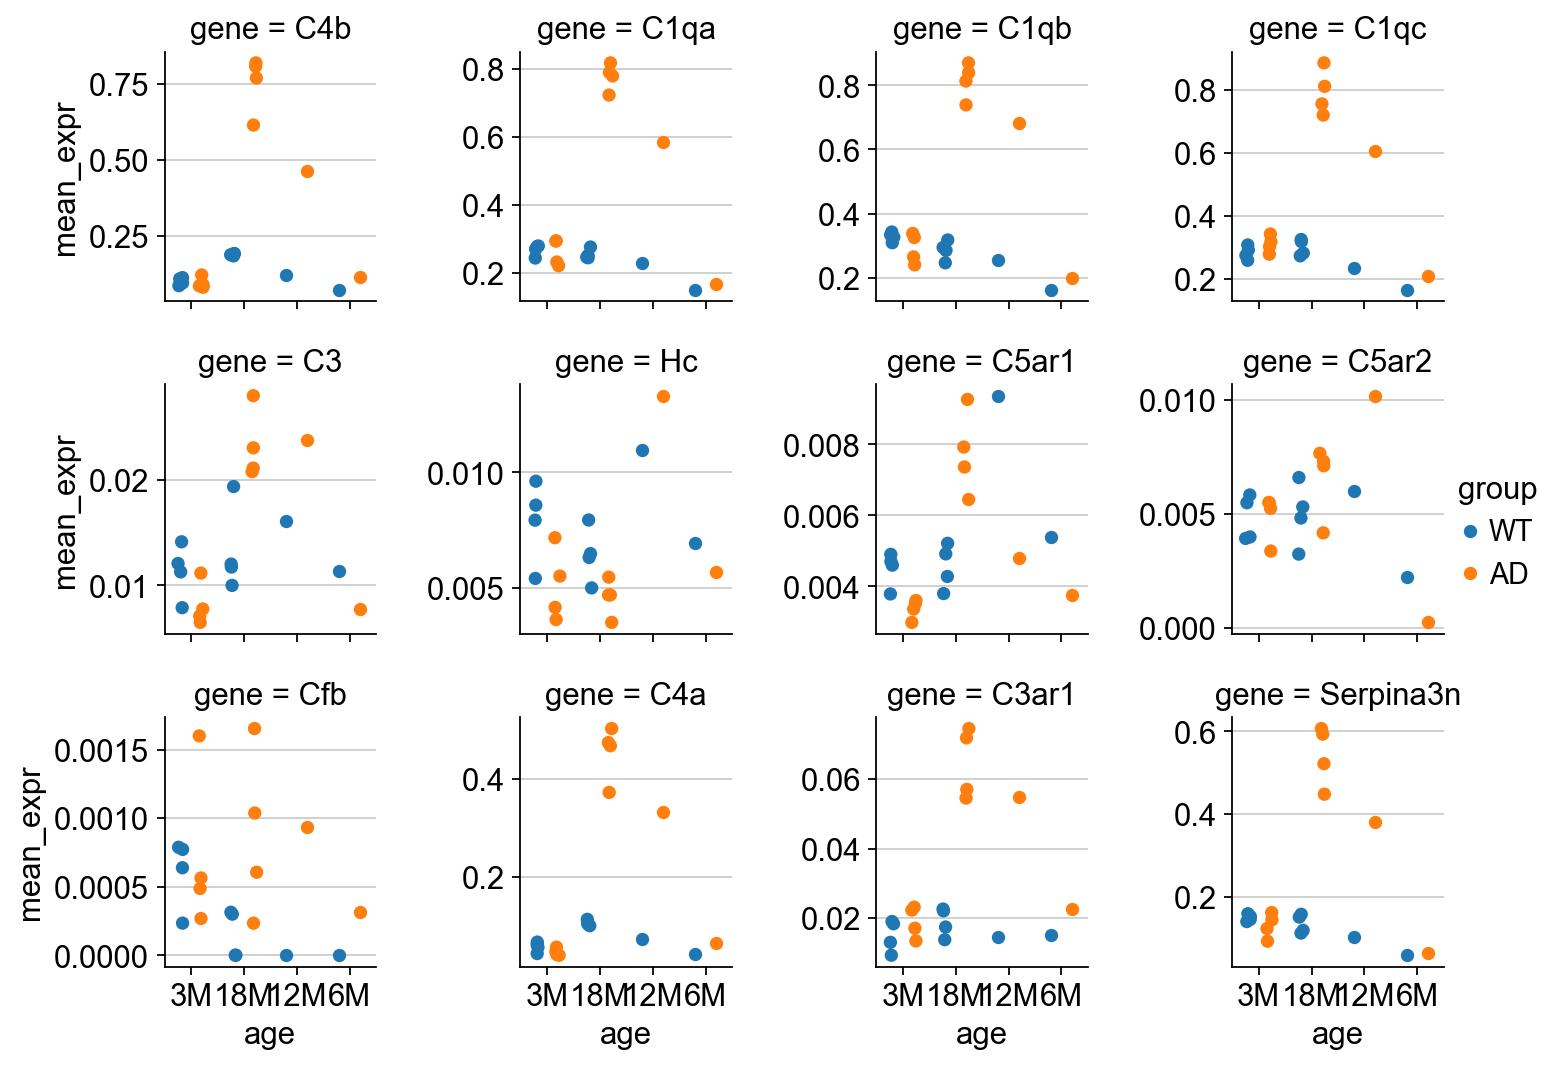

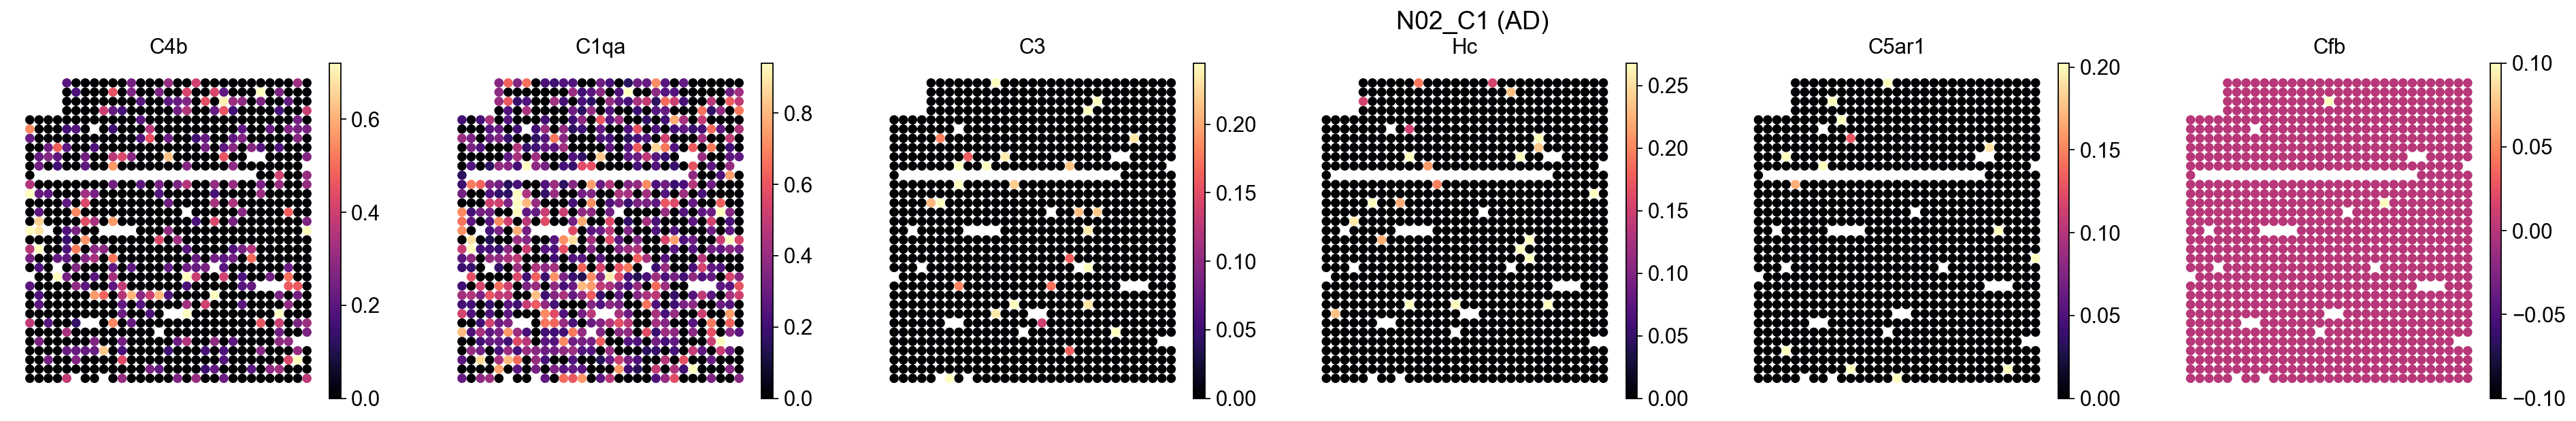

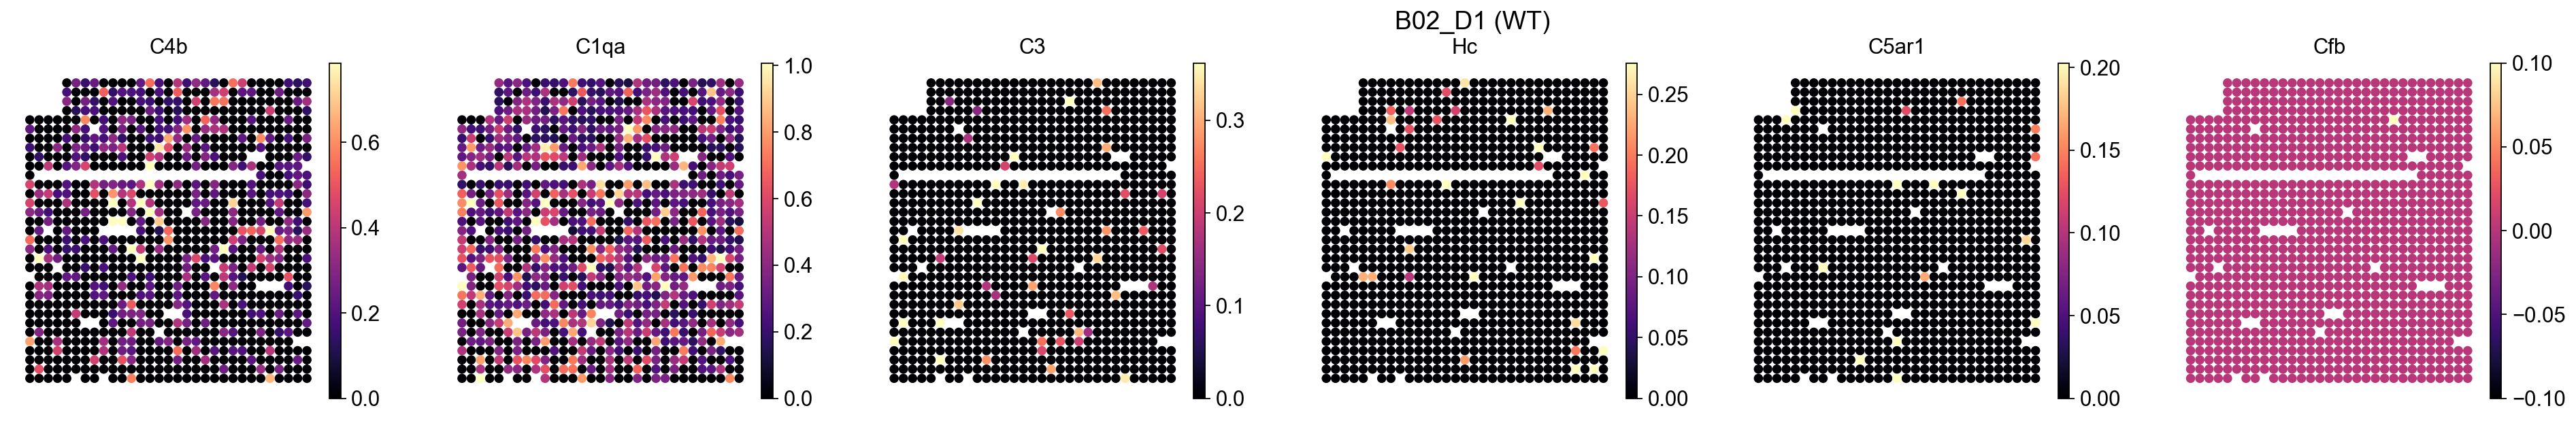

In [10]:
sp_names = [n for n in DATA if DATA[n].obs["modality"].iloc[0] == "spatial"]
for name in sp_names:
    a = DATA[name]
    genes = FOCUS + ["C4a", "C3ar1", "Serpina3n"]
    print(f"=== {name}: {a.n_obs} spots, samples={a.obs['sample'].nunique()}, groups={a.obs['group'].value_counts().to_dict()}")
    if "age" in a.obs:
        a.obs["group_age"] = a.obs["group"].astype(str) + "_" + a.obs["age"].astype(str)
        print("mean log-expression by genotype x age:"); display(mean_table(a, genes, "group_age", min_cells=30).round(3))
    co = coexpression_with_anchor(a, "C4b", [g for g in genes if g != "C4b"])
    r = resolve(a, ["C4b"])
    rho, rk = genome_wide_rank(a, r["C4b"], [sym("mouse", g) for g in genes if g != "C4b"])
    print("co-expression with C4b across spots:"); display(co.join(rk["rank"]).round(4))
    print("top-30 C4b-correlated genes across spots:", ", ".join(rho.head(30).index))
    # pseudobulk per sample: AD vs WT
    pb = pseudobulk(a, genes, extra=("group", "age") if "age" in a.obs else ("group",))
    tidy = pb.melt(id_vars=[c for c in pb.columns if c not in genes], value_vars=[g for g in genes if g in pb.columns], var_name="gene", value_name="mean_expr")
    g = sns.catplot(data=tidy, x="age" if "age" in pb.columns else "group", y="mean_expr", hue="group", col="gene", col_wrap=4, kind="strip", sharey=False, height=2.3, size=6, dodge=True)
    plt.show()
    # spatial maps for one AD and one WT section if coordinates exist
    if "spatial" in a.obsm:
        pick = a.obs.groupby("group", observed=True)["sample"].agg(lambda s: s.value_counts().index[0])
        for grp, smp in pick.items():
            sub = a[a.obs["sample"] == smp]
            hv = [sym("mouse", g) for g in ["C4b", "C1qa", "C3", "Hc", "C5ar1", "Cfb"] if sym("mouse", g) in a.var_names]
            sc.pl.spatial(sub, color=hv, spot_size=1.0, cmap="magma", vmax="p99", ncols=len(hv), show=False)
            plt.suptitle(f"{smp} ({grp})", y=1.02); plt.show()

## 7. Cross-dataset summary

In [11]:
# one table: per dataset, detection of each focus gene in oligodendrocytes (all groups pooled) and in microglia
summ = []
for name, a in DATA.items():
    if a.obs["modality"].iloc[0] == "spatial":
        continue
    for ct in ["Oligodendrocyte", "Microglia"]:
        sub = a[a.obs["cell_type_coarse"] == ct]
        if sub.n_obs < 30:
            continue
        df = expr_df(sub, FOCUS)
        row = {"dataset": name, "cell_type": ct, "n": sub.n_obs}
        row.update({g: (df[g] > 0).mean() for g in df.columns})
        summ.append(row)
SUMM = pd.DataFrame(summ).set_index(["dataset", "cell_type"])
display(SUMM.round(3))

n    C4b   C1qa   C1qb   C1qc     C3     Hc  C5ar1  C5ar2    Cfb
dataset                         cell_type                                                                            
Absinta2021_MS_human_snRNA      Oligodendrocyte  45697  0.000  0.004  0.008  0.004  0.006  0.046  0.006  0.001  0.000
                                Microglia         5432  0.000  0.214  0.346  0.238  0.447  0.034  0.112  0.045  0.000
Aging_snRNA_HIP_CP_mouse        Oligodendrocyte  19593  0.130  0.013  0.012  0.010  0.000  0.000  0.001  0.001  0.001
                                Microglia         3112  0.027  0.291  0.419  0.359  0.000  0.001  0.083  0.070  0.002
Jakel2019_MS_human_snRNA        Oligodendrocyte   7973  0.000  0.006  0.008  0.004  0.010  0.022  0.002  0.000    NaN
                                Microglia          428  0.000  0.266  0.418  0.343  0.418  0.005  0.091  0.000    NaN
Kaya2022_aged_WM_vs_GM_scRNA    Oligodendrocyte  15776  0.768  0.306  0.285  0.185  0.001  0.000  0.002  0.003  0.000
                                Microglia         5054  0.100  0.991  0.988  0.984  0.015  0.000  0.384  0.384  0.001
Park2023_AD_hippocampus_scRNA   Oligodendrocyte  10237  0.063  0.336  0.361  0.278  0.000  0.000  0.009  0.003  0.000
                                Microglia        13952  0.010  0.979  0.979  0.972  0.001  0.000  0.207  0.064  0.001
Ximerakis2019_aging_brain_scRNA Oligodendrocyte  12384  0.155  0.039  0.041  0.029  0.000  0.000  0.000  0.000    NaN
                                Microglia         3910  0.009  0.999  0.998  0.997  0.002  0.000  0.271  0.118    NaN
Zhou2020_5XFAD_snRNA            Oligodendrocyte  17356  0.124  0.057  0.055  0.054  0.000  0.000  0.003  0.001  0.000
                                Microglia         4152  0.018  0.788  0.760  0.843  0.000  0.000  0.056  0.040  0.000

### Interpretation

**Scope.** Eight public datasets (five mouse single-cell/nucleus, one mouse spatial, two human MS snRNA-seq), all whole-transcriptome, processed with one pipeline and a shared coarse annotation. Oligodendrocyte and microglia labels were checked against Plp1/PLP1 and Hexb (≈100 % and 92–100 % detection respectively in every mouse dataset); OPC/neuron labels in the Park dataset are unreliable and were not used.

**C4b itself.** In oligodendrocytes, C4b goes up with age in every aging dataset (pseudobulk log2FC ≈ 2.0–2.8, MWU p < 0.05 in aging snRNA-seq and Ximerakis) and is far higher in aged white than grey matter (Kaya: 77 % of WM oligodendrocytes C4b⁺, log2FC 2.5). It is up 2.8 log2 in 5XFAD oligodendrocytes (Zhou). It did not rise in the pooled Park App^NL-G-F^ hippocampus samples (one library per age × genotype, so no power). In the Chen Spatial Transcriptomics data C4b climbs from 0.19 (WT 18 mo) to 0.75 (AD 18 mo) mean log-expression and its top-30 spot-level correlates are the plaque-induced / DAM genes (C4a, Cst7, Gfap, Ctsd, Tyrobp, Trem2, Apoe, C1qa-c, Serpina3n). Human C4A/C4B could **not** be evaluated: both genes have <25 total counts in 17–66 k nuclei in Jäkel and Absinta, the signature of multi-mapping reads between the near-identical C4A/C4B paralogs being discarded by the aligner, not of biological absence.

**C5 (Hc / C5).** Mouse: ≤0.3 % of cells of any type in all six mouse datasets, no disease or age change. Human: C5 is detected in 2–7 % of oligodendrocytes, OPCs and astrocytes in both MS datasets (Absinta: 7 % of control-WM oligodendrocytes, 3–6 % in lesions; Jäkel: 3.4 % control → 1.2–1.7 % in lesions, log2FC −1.5, p = 0.004), i.e. a low but real glial C5 transcript exists in human white matter and, if anything, goes *down* in MS oligodendrocytes. It is not correlated with anything in the complement panel.

**C5a receptors.** C5ar1 is myeloid in every dataset: 6–38 % of microglia (highest in aged white matter, Kaya 38 %) and 11–26 % of infiltrating/other immune cells, versus ≤0.9 % of oligodendrocytes in all seven single-cell datasets and 0.2–0.6 % in human MS oligodendrocytes. C5ar2 follows the same pattern at lower levels (4–38 % of microglia; ≤0.3 % of oligodendrocytes). So the in-house conclusion that C4b⁺ oligodendrocytes do not express C5a receptors holds across AD, aging, white-matter aging and human MS. Microglial C5ar1 tends to increase with disease (Jäkel MS 2.9 log2, Absinta 0.8, Park AD 0.9, 5XFAD −0.2; none reach significance with the available replicate numbers) and in Absinta the highest C5AR1 detection is at chronic active lesion edges (14.5 % vs 4.5 % in control WM). In the spatial AD data C5ar1 barely tracks C4b across spots (Spearman 0.02, rank 5,564), unlike C1q (rank 11–18).

**C1q.** Microglial everywhere (76–100 % of mouse microglia; 21–42 % of human MS microglia nuclei). Inside oligodendrocytes, C1q detection is 30–36 % in the two droplet scRNA-seq datasets (Park, Kaya) but only 1–6 % in the snRNA-seq datasets; that gap is ambient RNA from microglia in whole-cell preparations, so C1q "in" oligodendrocytes should not be read as intrinsic. C1q co-varies with C4b at the tissue level (Chen ST: rank 11–18 of ~14 k genes, ρ ≈ 0.33; 3-fold higher in AD 18 mo spots) and modestly at the nucleus level in 5XFAD oligodendrocytes (rank 233–482), but not in aging (rank > 2,800) and negatively in Kaya (grey-matter oligodendrocytes carry more ambient C1q than white-matter ones).

**Cfb.** Essentially silent outside EAE: ≤0.2 % of microglia and ≤0.1 % of oligodendrocytes in every AD and aging dataset, ≤0.1 % of spots in Chen ST, and 6 counts in 66 k nuclei in Absinta (not annotated in Jäkel). Together with the in-house Xenium EAE result (Cfb in 67 % of lesion macrophages, induced 10-fold in microglia), this makes Cfb a marker of active inflammatory demyelination rather than of the age- or amyloid-associated C4b⁺ oligodendrocyte state.

**Genome-wide view inside oligodendrocytes.** In every mouse dataset with a C4b⁺ population, Serpina3n is the #1 (Kaya, Ximerakis, Zhou) or top-1 % (Park, rank 109) C4b-correlated gene, followed by the MHC-I/interferon module (H2-D1, B2m, H2-K1, Ifi27, Irf9, Stat3), Klk6, Apod, Trf, Cd9, Cldn11 — the same program described in the in-house data. No complement receptor and neither Cfb nor Hc ranks in the top 1,000 in any dataset; the only complement genes that do are C4a (Chen ST, rank 1; Kaya 4-fold detection enrichment) and the membrane regulators Cd59a (Kaya rank 269, Ximerakis rank 117) and Cr1l/Crry (Kaya rank 1,105, Park rank 1,252), i.e. C4b⁺ oligodendrocytes up-regulate protection against complement deposition rather than complement receptors.

**Caveats.** (1) Coarse annotation is marker-based for Park, aging snRNA-seq, Zhou and Kaya; only oligodendrocyte and microglia labels were validated. (2) Pseudobulk tests are underpowered for Park (3 vs 3 pooled libraries) and for the human datasets (1–2 control donors in Jäkel microglia); treat those log2FCs as descriptive. (3) The Kaya 10x libraries are all 24-month-old, so the comparison is white vs grey matter in aged brain, not young vs aged. (4) Human C4A/C4B are not quantifiable in standard Cell Ranger output; a multi-mapping-aware re-quantification (e.g. STARsolo with EM or an alignment to a C4A/C4B-merged reference) would be needed to look at human C4 in these data.